<a href="https://colab.research.google.com/github/seojoon1/2026_bigdatacomputing/blob/main/20250573%EA%B9%80%EC%84%9C%EC%A4%80_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  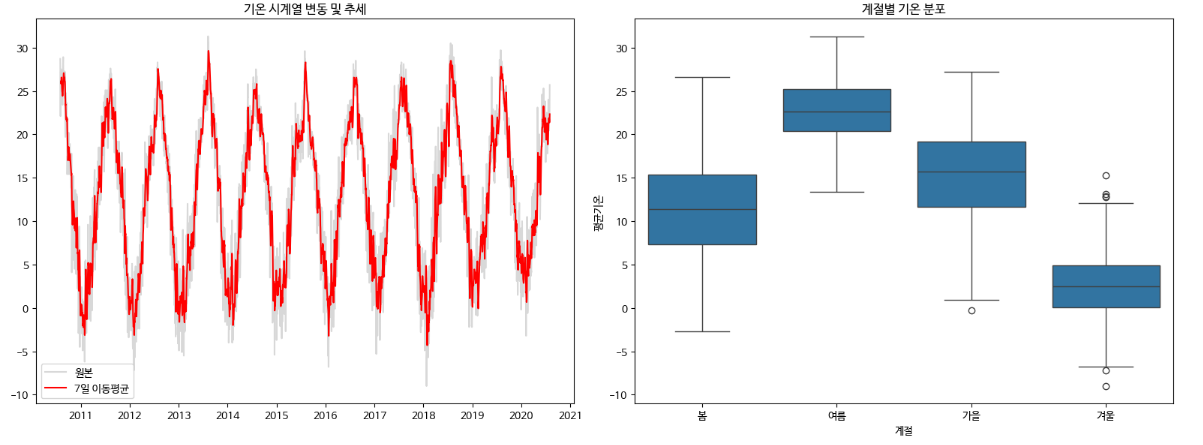

  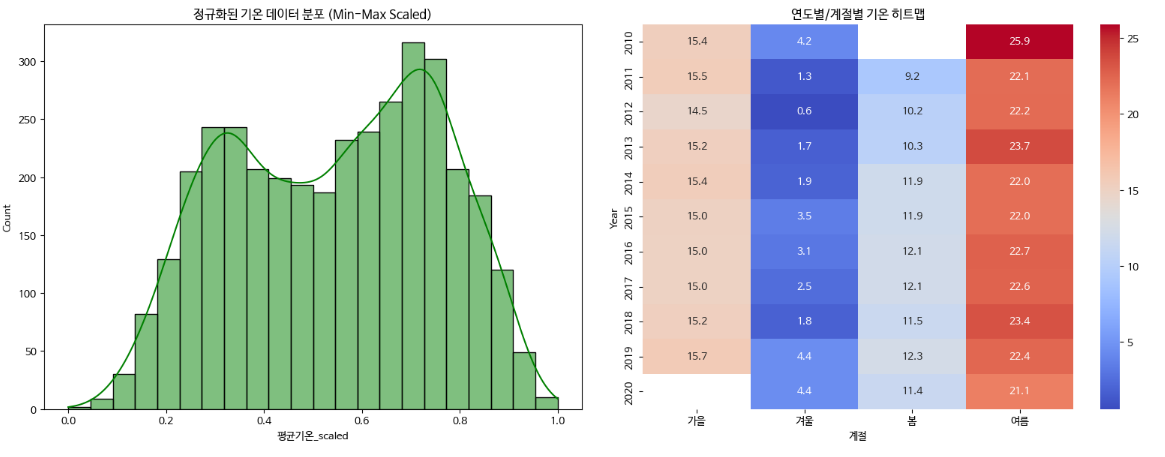



In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def setup_korean_font():
    """한글 폰트 설정"""
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

    # 1. 폰트 설치 확인
    if not os.path.exists(font_path):
        print("Installing Nanum fonts...")
        os.system('apt-get install -y fonts-nanum > /dev/null 2>&1')
        os.system('fc-cache -fv > /dev/null 2>&1')

        cache_dir = fm.get_cachedir()
        for f in os.listdir(cache_dir):
            if f.startswith('fontlist'):
                os.remove(os.path.join(cache_dir, f))

    # 2. 폰트 등록
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()

    # 3. 전역 설정
    plt.rc('font', family=font_name)
    plt.rcParams['axes.unicode_minus'] = False
    print(f"✅ 한글 폰트 설정 완료: {font_name}")

setup_korean_font()

✅ 한글 폰트 설정 완료: NanumBarunGothic


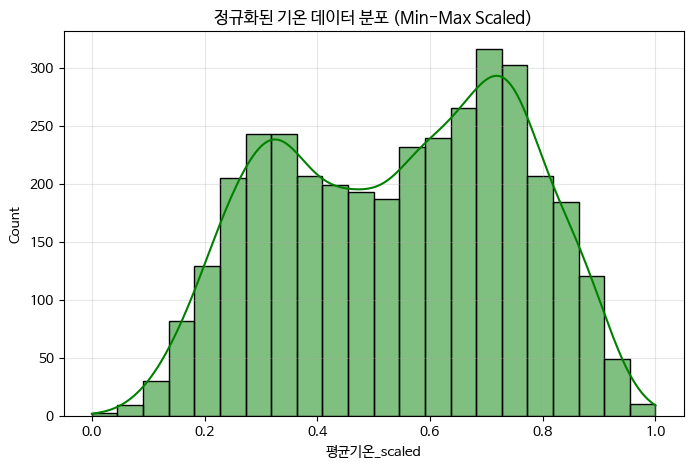

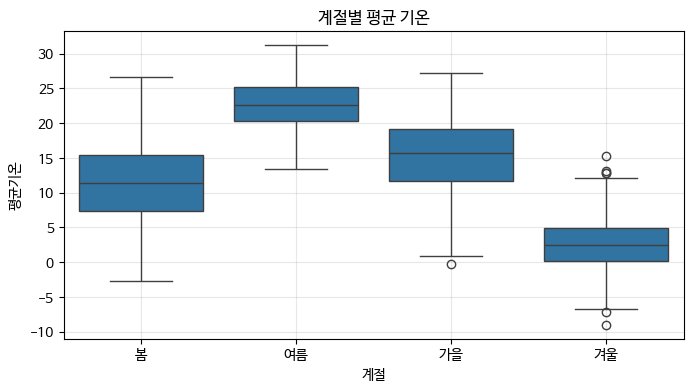

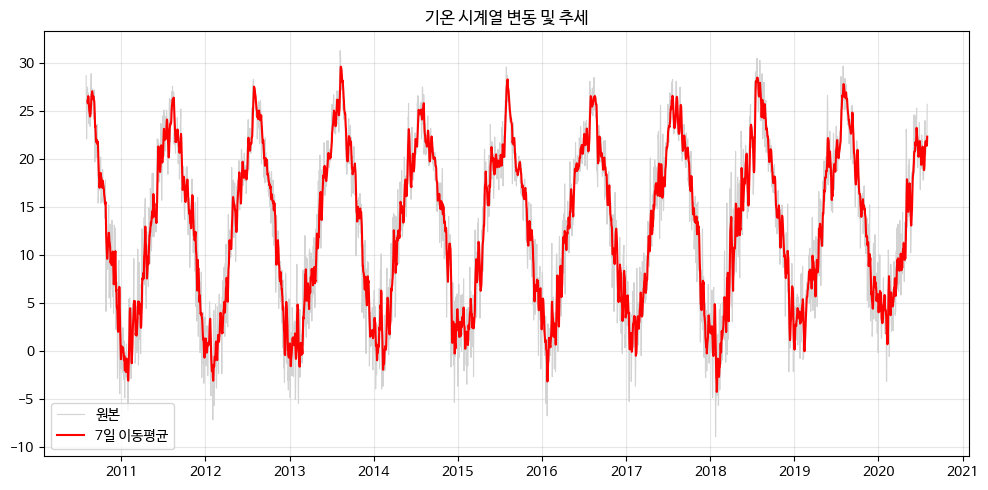

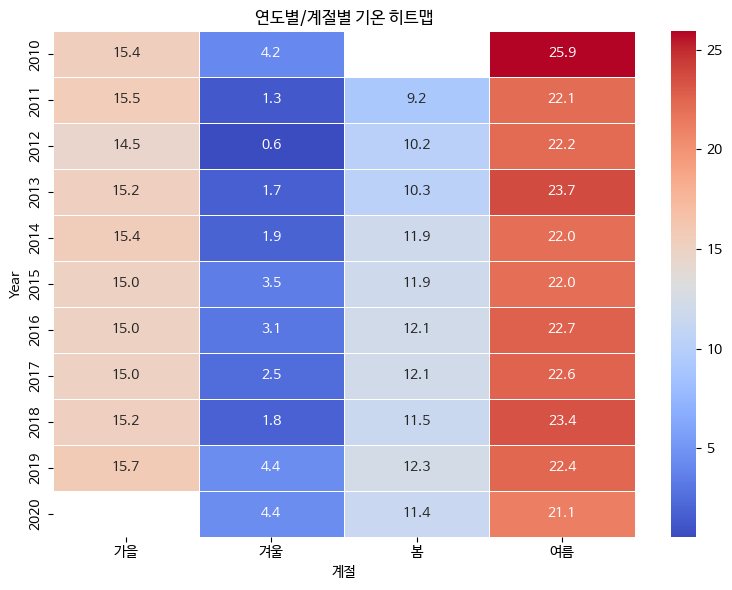

✅ 엑셀 저장 완료: weather_analysis_report.xlsx


In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

URL = "https://github.com/dongupak/DataML/raw/main/csv/weather.csv"


def get_season(d):
    if d.month in [3, 4, 5]: return '봄'
    elif d.month in [6, 7, 8]: return '여름'
    elif d.month in [9, 10, 11]: return '가을'
    else: return '겨울'


def load_data():
    """CSV 로드"""
    return pd.read_csv(URL, encoding="cp949")


def preprocess(df):
    """날짜 변환 + 계절 컬럼 + 인덱스 설정 + 결측치 처리"""
    df = df.copy()
    df["일시"] = pd.to_datetime(df["일시"])
    df["계절"] = df["일시"].apply(get_season)
    df = df.set_index("일시")
    df = df.ffill()
    return df


def minMaxAvgTemp(df):
    def min_max_scale(s):
        return (s - s.min()) / (s.max() - s.min())
    df["평균기온_scaled"] = min_max_scale(df["평균기온"])
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x="평균기온_scaled",
                 kde=True, edgecolor='black', color="green")
    plt.title('정규화된 기온 데이터 분포 (Min-Max Scaled)')
    plt.xlabel("평균기온_scaled")
    plt.ylabel('Count')
    plt.grid(alpha=0.3)
    plt.show()


def seasonAvgTemp(df):
    plt.figure(figsize=(8, 4))
    plt.title("계절별 평균 기온")
    sns.boxplot(data=df, x="계절", y="평균기온",
                order=['봄', '여름', '가을', '겨울'])
    plt.grid(alpha=0.3)
    plt.show()


def plot_timeseries_with_ma(df):
    df['평균기온_MA7'] = df['평균기온'].rolling(7).mean()
    plt.figure(figsize=(10, 5))
    plt.plot(df.index, df['평균기온'], color='lightgray', linewidth=0.8, label='원본')
    plt.plot(df.index, df['평균기온_MA7'], color='red', linewidth=1.5, label='7일 이동평균')
    plt.title('기온 시계열 변동 및 추세')
    plt.legend(loc='lower left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_season_heatmap(df):
    pivot = pd.pivot_table(df, values='평균기온',
                           index=df.index.year, columns='계절',
                           aggfunc='mean')
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot, annot=True, fmt='.1f',
                cmap='coolwarm', linewidths=0.5)
    plt.title('연도별/계절별 기온 히트맵')
    plt.xlabel('계절')
    plt.ylabel('Year')
    plt.tight_layout()
    plt.show()


def get_season_stats(df):
    return df.groupby('계절').agg({
        '평균기온': ['mean', 'std', 'min', 'max'],
        '최대풍속': ['mean', 'max'],
        '평균풍속': 'mean'
    }).round(2)


def get_yearly_pivot(df):
    return pd.pivot_table(df, values='평균기온',
                          index=df.index.year, columns=df.index.month,
                          aggfunc='mean').round(2)


def export_to_excel(df, season_stats, yearly_pivot):
    path = 'weather_analysis_report.xlsx'
    with pd.ExcelWriter(path, engine='openpyxl') as writer:
        df.to_excel(writer, sheet_name='전처리데이터')
        season_stats.to_excel(writer, sheet_name='계절별통계')
        yearly_pivot.to_excel(writer, sheet_name='연도별피벗')
    print(f"✅ 엑셀 저장 완료: {path}")


def main():
    df = load_data()
    df = preprocess(df)
    minMaxAvgTemp(df)
    seasonAvgTemp(df)
    plot_timeseries_with_ma(df)
    plot_season_heatmap(df)
    season_stats = get_season_stats(df)
    yearly_pivot = get_yearly_pivot(df)
    export_to_excel(df, season_stats, yearly_pivot)


main()